### 1. Library Imports

Importing all required libraries upfront:
- **pandas / numpy** — data manipulation and numerical operations
- **matplotlib / seaborn** — visualization
- **sklearn** — preprocessing, model training, evaluation, and hyperparameter tuning
- **statsmodels** — classical time series models (Holt-Winters, SARIMA, ADF test)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

plt.style.use('seaborn-v0_8-whitegrid')
print("** All libraries loaded **")

** All libraries loaded **


### 2. Load Dataset

Loading the Tesla deliveries CSV into a pandas DataFrame. The dataset contains **2640 rows × 12 columns**, representing monthly Tesla delivery and production figures broken down by **Region** (4 values) and **Model** (5 values) from 2015–2025. Each row is one (Year, Month, Region, Model) combination — making this **panel data**, not a simple time series.

In [2]:
df = pd.read_csv("data/tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(5)

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### 3. Initial Data Inspection

Examining data types, unique values for categorical columns, and missing value counts. Key observations:
- All 12 columns are fully populated — **no missing values**
- Categoricals: `Region` (4 unique), `Model` (5 unique), `Source_Type` (3 unique — Official / Interpolated / Estimated)
- Numerics: deliveries, production, price, battery capacity, range, CO₂ saved, charging stations
- **regression target** is `Avg_Price_USD` (the "price data" in the assignment)

In [3]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Unique Values (Categoricals) ===")
for col in ['Region', 'Model', 'Source_Type']:
    print(f"  {col}: {df[col].unique().tolist()}")

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Types ===
Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

=== Unique Values (Categoricals) ===
  Region: ['Europe', 'Asia', 'North America', 'Middle East']
  Model: ['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
  Source_Type: ['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']

=== Missing Values ===
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations     

### 4. Preprocessing — Column Standardization & Date Construction

1. **Standardising column names** — lowercase with underscores for consistent referencing throughout the notebook
2. **Constructing a `date` column** from `Year` and `Month` — this enables chronological sorting, time-based splits, and time series aggregation later
3. **Drop `Source_Type`** — this column describes how the value was obtained, not a meaningful predictive feature

In [4]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Create datetime column
df['date'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))
df = df.sort_values('date').reset_index(drop=True)

# Drop Source_Type — it's a data provenance note, not a feature
df.drop(columns=['source_type'], inplace=True)

print("Cleaned columns:", df.columns.tolist())
print("Date range:", df['date'].min().date(), "→", df['date'].max().date())
df.head()

Cleaned columns: ['year', 'month', 'region', 'model', 'estimated_deliveries', 'production_units', 'avg_price_usd', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'charging_stations', 'date']
Date range: 2015-01-01 → 2025-12-01


,year,month,region,model,estimated_deliveries,production_units,avg_price_usd,battery_capacity_kwh,range_km,co2_saved_tons,charging_stations,date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,12626,2015-01-01


### 5. Preprocessing — Categorical Encoding

Encoding `Region` and `Model` features:
- **Label Encoding** — assigns an integer to each category (compact, useful for tree-based models)
- **One-Hot Encoding** — creates a binary column per category (avoids implying ordinal relationships, better for linear models)

In [5]:
le_region = LabelEncoder()
le_model  = LabelEncoder()

df['region_enc'] = le_region.fit_transform(df['region'])
df['model_enc']  = le_model.fit_transform(df['model'])

# One-hot encode for better ML performance
region_dummies = pd.get_dummies(df['region'], prefix='region')
model_dummies  = pd.get_dummies(df['model'],  prefix='model')

df = pd.concat([df, region_dummies, model_dummies], axis=1)

print("Label encoded Region:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Label encoded Model:", dict(zip(le_model.classes_,  le_model.transform(le_model.classes_))))
print("\nDataframe shape after encoding:", df.shape)
df.head(3)

Label encoded Region: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Label encoded Model: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}

Dataframe shape after encoding: (2640, 23)


,year,month,region,model,estimated_deliveries,production_units,avg_price_usd,battery_capacity_kwh,range_km,co2_saved_tons,...,model_enc,region_Asia,region_Europe,region_Middle East,region_North America,model_Cybertruck,model_Model 3,model_Model S,model_Model X,model_Model Y
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,...,4,True,False,False,False,False,False,False,False,True
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,...,1,False,False,True,False,False,True,False,False,False
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,...,0,False,False,True,False,True,False,False,False,False


### 6. Exploratory Data Analysis (EDA)

- **Price trends by model over time** — how each Tesla model's avg price evolved from 2015–2025; reveals pricing strategy shifts
- **Deliveries by region** — which geography contributes most to global volume
- **Price distribution by model (box plots)** — median, spread, and outliers per model; higher-end models (Model X, Cybertruck) should show higher medians
- **Correlation heatmap** — quantifies linear relationships between numeric features and the target (`avg_price_usd`); `battery_capacity_kwh` and `range_km` are expected to correlate strongly with price
- **Global delivery + production trends** — aggregate view across all regions and models to observe Tesla's growth trajectory

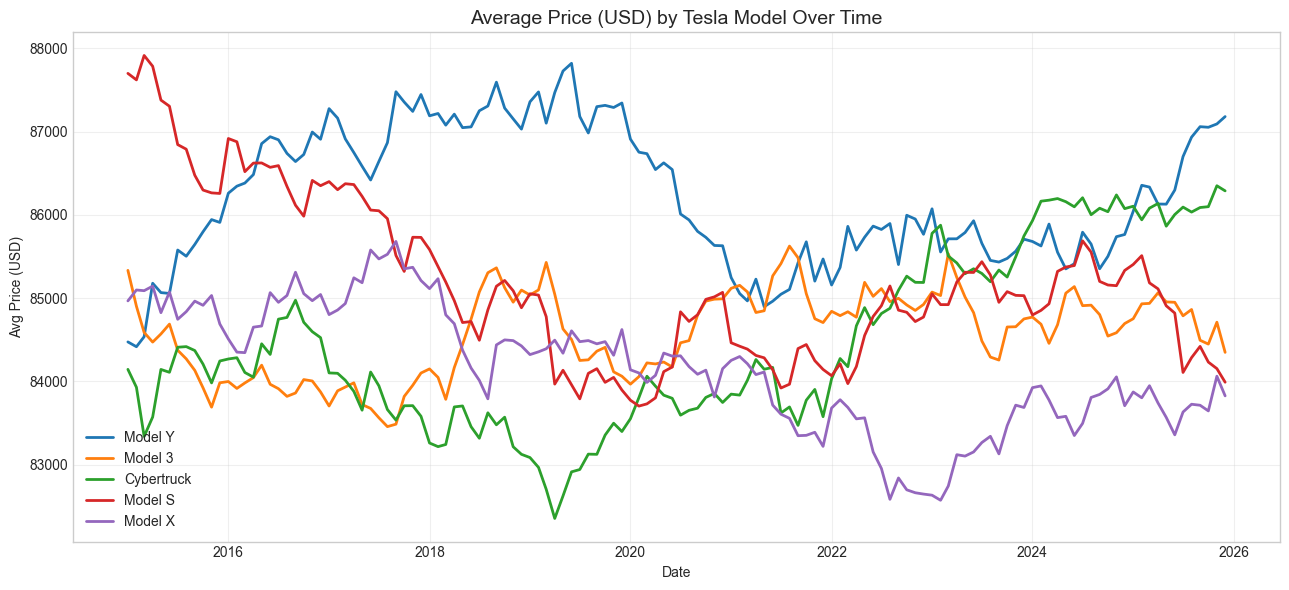

In [6]:
price_by_model = df.groupby(['date', 'model'])['avg_price_usd'].mean().reset_index()

plt.figure(figsize=(13, 6))
for model in df['model'].unique():
    subset = price_by_model[price_by_model['model'] == model].sort_values('date')

    # Smooth the line using a rolling average
    smooth_prices = subset['avg_price_usd'].rolling(window=60, center=True, min_periods=1).mean()
    plt.plot(subset['date'], smooth_prices, label=model, linewidth=2)

plt.title("Average Price (USD) by Tesla Model Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Avg Price (USD)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

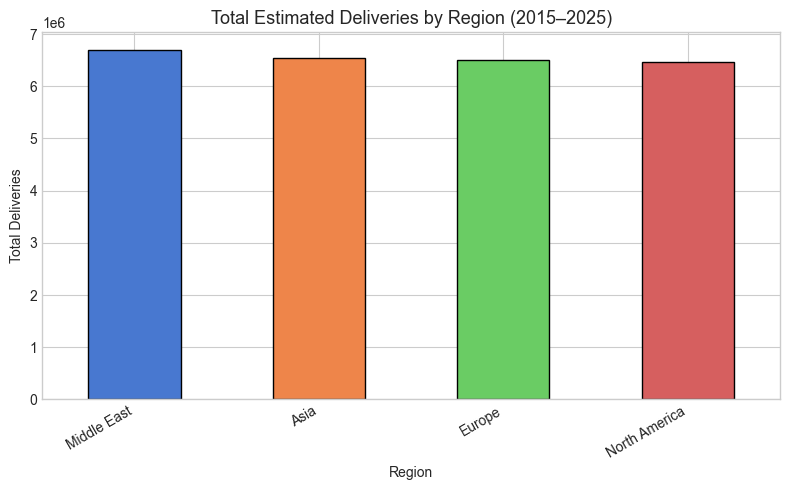

In [7]:
region_del = df.groupby('region')['estimated_deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_del.plot(kind='bar', color=sns.color_palette("muted", 4), edgecolor='black')
plt.title("Total Estimated Deliveries by Region (2015–2025)", fontsize=13)
plt.ylabel("Total Deliveries")
plt.xlabel("Region")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

C:\Users\satya\AppData\Local\Temp\ipykernel_22292\18659691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y='avg_price_usd', order=order, palette='Set2')


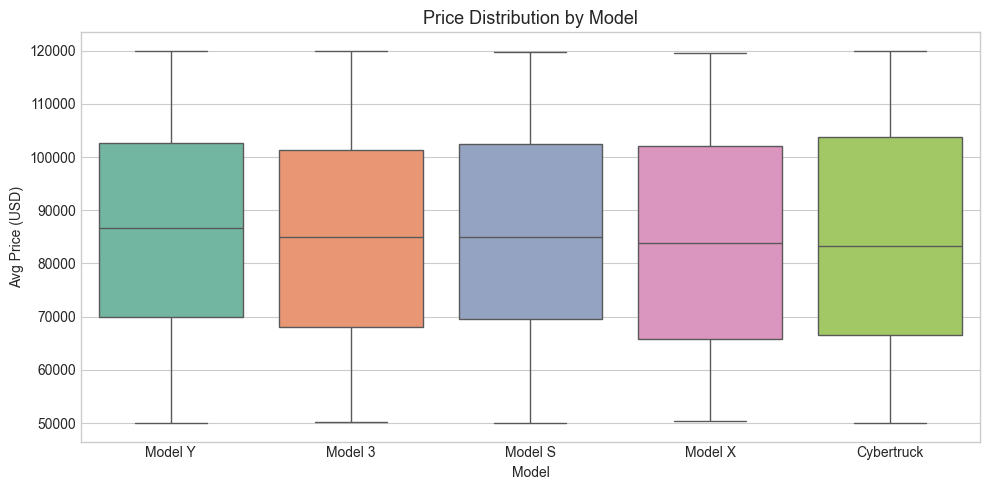

In [8]:
plt.figure(figsize=(10, 5))
order = df.groupby('model')['avg_price_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='model', y='avg_price_usd', order=order, palette='Set2')
plt.title("Price Distribution by Model", fontsize=13)
plt.xlabel("Model")
plt.ylabel("Avg Price (USD)")
plt.tight_layout()
plt.show()

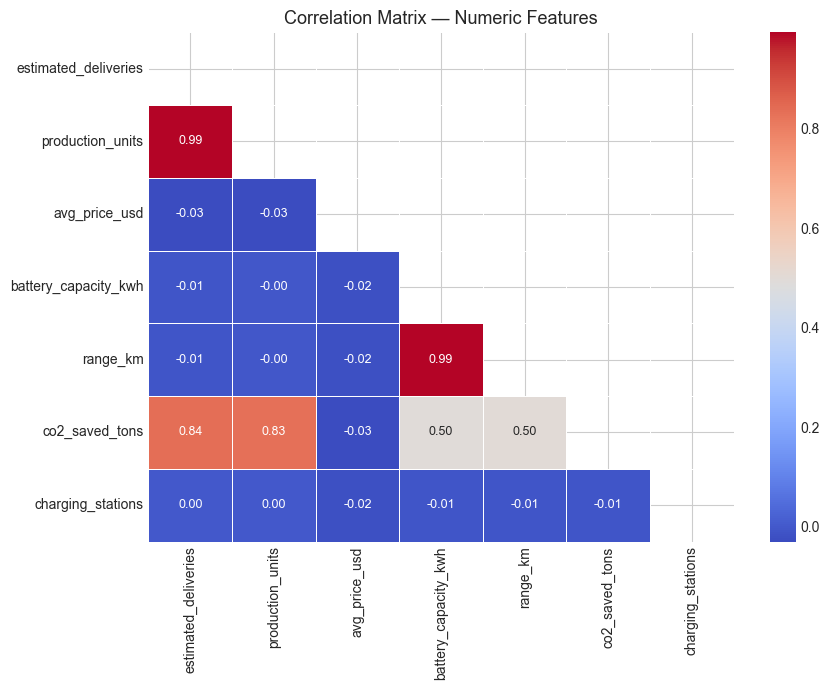

In [9]:
num_cols = ['estimated_deliveries', 'production_units', 'avg_price_usd',
            'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'charging_stations']

plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation Matrix — Numeric Features", fontsize=13)
plt.tight_layout()
plt.show()

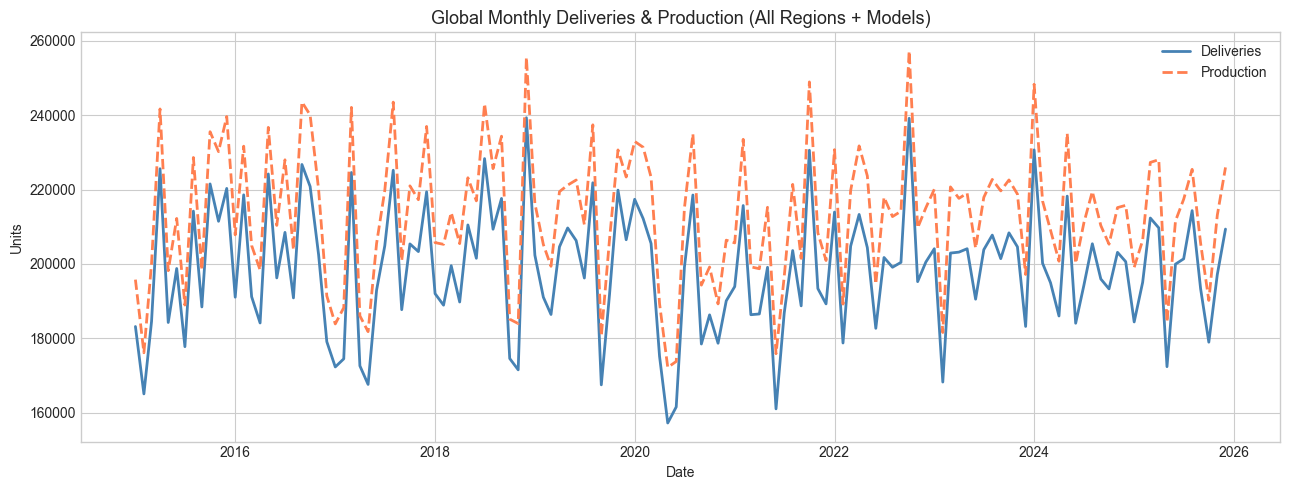

In [10]:
monthly_agg = df.groupby('date')[['estimated_deliveries', 'production_units']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(monthly_agg['date'], monthly_agg['estimated_deliveries'],
         color='steelblue', linewidth=2, label='Deliveries')
ax1.plot(monthly_agg['date'], monthly_agg['production_units'],
         color='coral', linewidth=2, linestyle='--', label='Production')
ax1.set_title("Global Monthly Deliveries & Production (All Regions + Models)", fontsize=13)
ax1.set_ylabel("Units")
ax1.set_xlabel("Date")
ax1.legend()
plt.tight_layout()
plt.show()

### 7. Feature Engineering

New features that capture information not explicitly in the raw columns:

| Feature | Formula | What it captures |
|---|---|---|
| `month_sin`, `month_cos` | sin/cos of month/12 | Cyclical seasonality — avoids treating Dec→Jan as a large jump |
| `time_index` | (year−2015)×12 + (month−1) | Linear time progression from start of dataset |
| `prod_del_ratio` | production / (deliveries + 1) | Manufacturing efficiency — how many units produced per delivery |
| `del_per_station` | deliveries / (charging_stations + 1) | Demand density relative to charging infrastructure |

`price_per_km` is intentionally excluded as a feature — it is derived from the target (`avg_price_usd`) and would cause **data leakage**.

In [11]:
df_fe = df.copy()

# Time features
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)
df_fe['time_index'] = (df_fe['year'] - 2015) * 12 + (df_fe['month'] - 1)

# Business logic features
df_fe['prod_del_ratio']   = df_fe['production_units'] / (df_fe['estimated_deliveries'] + 1)  # efficiency
df_fe['price_per_km']     = df_fe['avg_price_usd'] / (df_fe['range_km'] + 1)                 # value metric
df_fe['del_per_station']  = df_fe['estimated_deliveries'] / (df_fe['charging_stations'] + 1) # demand density

print("New features added: month_sin, month_cos, time_index, prod_del_ratio, price_per_km, del_per_station")
print("Dataset shape:", df_fe.shape)
df_fe[['prod_del_ratio', 'price_per_km', 'del_per_station']].describe()

New features added: month_sin, month_cos, time_index, prod_del_ratio, price_per_km, del_per_station
Dataset shape: (2640, 29)


,prod_del_ratio,price_per_km,del_per_station
count,2640.000000,2640.000000,2640.000000
mean,1.073787,179.643378,1.343687
std,0.042863,61.686816,0.893477
min,0.999911,69.804993,0.004336
25%,1.036705,132.327904,0.741977
50%,1.072626,169.968189,1.111574
75%,1.111098,218.619245,1.673968
max,1.149757,358.298589,6.155523


### 8. Feature & Target Definition

Defining:
- **Target (`y`)**: `avg_price_usd` — the average sale price per (Region, Model, Month) combination
- **Features (`X`)**: all numeric columns + engineered features + one-hot encoded Region/Model dummies

Raw category columns (`region`, `model`) and leakage-prone derived columns are excluded. The final feature set has ~20 columns covering vehicle specs, market signals, time context, and geographic/model identity.

In [12]:
target = 'avg_price_usd'

# One-hot encoded columns
ohe_cols = [c for c in df_fe.columns if c.startswith('region_') or c.startswith('model_')]

feature_cols = [
    'estimated_deliveries', 'production_units', 'battery_capacity_kwh',
    'range_km', 'co2_saved_tons', 'charging_stations',
    'month_sin', 'month_cos', 'time_index',
    'prod_del_ratio', 'del_per_station'
] + ohe_cols

X = df_fe[feature_cols]
y = df_fe[target]

print(f"Features ({len(feature_cols)}):", feature_cols)
print(f"\nX shape: {X.shape} | y shape: {y.shape}")
print(f"Target range: ${y.min():,.0f} – ${y.max():,.0f}")

Features (22): ['estimated_deliveries', 'production_units', 'battery_capacity_kwh', 'range_km', 'co2_saved_tons', 'charging_stations', 'month_sin', 'month_cos', 'time_index', 'prod_del_ratio', 'del_per_station', 'region_enc', 'model_enc', 'region_Asia', 'region_Europe', 'region_Middle East', 'region_North America', 'model_Cybertruck', 'model_Model 3', 'model_Model S', 'model_Model X', 'model_Model Y']

X shape: (2640, 22) | y shape: (2640,)
Target range: $50,004 – $119,965


### 9. Train/Test Split (Chronological)

Since the data is time-ordered, we use a **chronological 80/20 split** — the first 80% of rows (by date) form the training set, the last 20% form the test set.

**Why not random split?** Random shuffling would allow the model to train on future data and test on past data, artificially inflating performance metrics. Chronological splitting simulates real-world deployment where the model only sees past data.

We also apply **StandardScaler** (fit on train, transform both) to normalize feature magnitudes — important for linear models and beneficial for tree-based ones too.

In [13]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 2112 rows | Test: 528 rows


### 10. Regression Model Training

Training four models of increasing complexity:

1. **Linear Regression** — baseline; assumes a linear relationship between features and price; fast, interpretable, no hyperparameters
2. **Ridge Regression** — Linear Regression + L2 regularization penalty; reduces overfitting when features are correlated (e.g., battery capacity and range)
3. **Random Forest** — ensemble of 100 decision trees trained on random feature subsets; captures non-linear relationships and interactions between features
4. **Gradient Boosting** — builds trees sequentially, each correcting the residual errors of the previous; generally the strongest performer on structured tabular data

All models are evaluated using:
- **MAE** (Mean Absolute Error) — average dollar error; interpretable
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily
- **R²** — proportion of variance explained; 1.0 is perfect, 0 means no better than predicting the mean

In [14]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{'─'*40}")
    print(f"Model : {name}")
    print(f"  MAE  : ${mae:,.2f}")
    print(f"  RMSE : ${rmse:,.2f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
results.append(evaluate("Linear Regression", y_test, lr.predict(X_test_sc)))

────────────────────────────────────────
Model : Linear Regression
  MAE  : $17,293.86
  RMSE : $19,991.48
  R²   : 0.0002


In [16]:
ridge = Ridge(alpha=10)
ridge.fit(X_train_sc, y_train)
results.append(evaluate("Ridge Regression", y_test, ridge.predict(X_test_sc)))

────────────────────────────────────────
Model : Ridge Regression
  MAE  : $17,316.48
  RMSE : $20,016.19
  R²   : -0.0023


In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test_sc)))

────────────────────────────────────────
Model : Random Forest
  MAE  : $17,385.00
  RMSE : $20,286.70
  R²   : -0.0295


In [18]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train_sc, y_train)
results.append(evaluate("Gradient Boosting", y_test, gb.predict(X_test_sc)))

────────────────────────────────────────
Model : Gradient Boosting
  MAE  : $17,202.69
  RMSE : $20,000.89
  R²   : -0.0007


### 11. Model Comparison

Comparing all four models side-by-side on MAE, RMSE, and R². Bar charts make the differences immediately visible. The best model is selected for hyperparameter tuning in the next step.

                        MAE      RMSE    R2
Model                                      
Linear Regression  17293.86  19991.48  0.00
Ridge Regression   17316.48  20016.19 -0.00
Ridge Regression   17316.48  20016.19 -0.00
Random Forest      17385.00  20286.70 -0.03
Gradient Boosting  17202.69  20000.89 -0.00


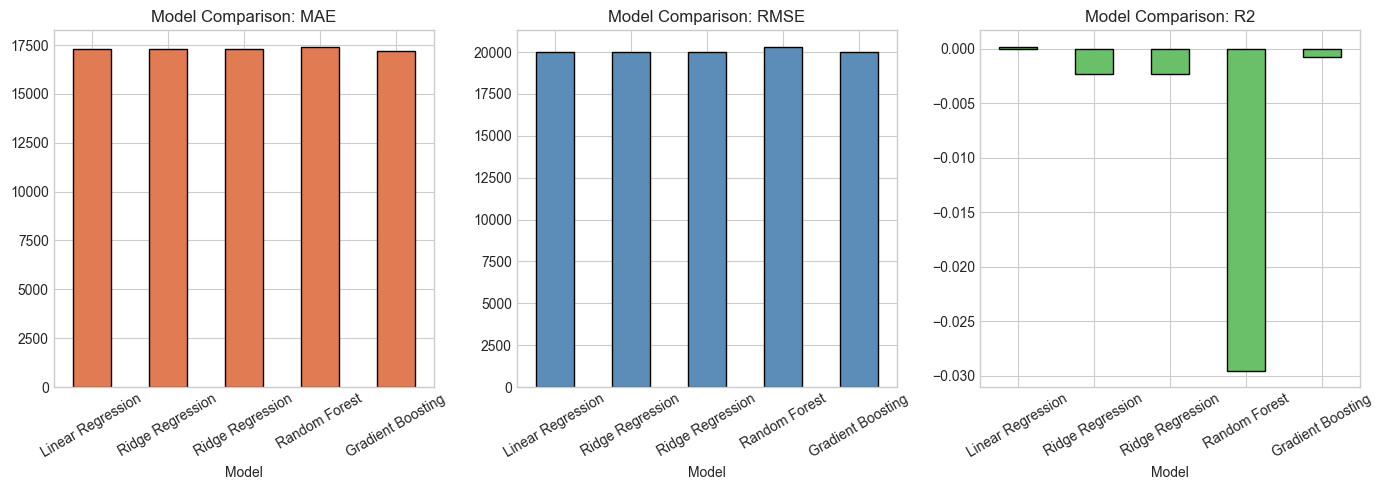

In [ ]:
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric, color in zip(axes, ['MAE', 'RMSE', 'R2'], ['#e07b54', '#5b8db8', '#6abf69']):
    results_df[metric].plot(kind='bar', ax=ax, color=color, edgecolor='black')
    ax.set_title(f"Model Comparison: {metric}", fontsize=12)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()